# MLP Model Development

This notebook builds, trains and evaluates the **Multi-Layer Perceptron (MLP)**
for phishing URL classification. 

## Objective
Build a fully-connected feed-forward network that takes the 50 preprocessed,
scaled numerical features for a URL/website and predicts whether it is
**Legitimate** or **Phishing**.


### 1. Imports

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import logging
logging.getLogger("tensorflow").setLevel(logging.ERROR)  

import sys
import time
from pathlib import Path


import numpy as np
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping

# Project root, so we can import from src/ and models/
PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

from models.mlp import build_mlp
from src.evaluation import (
    calculate_metrics,
    plot_confusion_matrix,
    plot_roc_curve,
    plot_training_history
)

print("Libraries imported successfully.")


Libraries imported successfully.


### 2. Fix the random seed

Every member must use seed **42** so results are comparable.

In [2]:
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)


### 3. Load the preprocessed data

In [3]:
X_train = np.load("../data/processed/X_train.npy")
X_val = np.load("../data/processed/X_val.npy")
X_test = np.load("../data/processed/X_test.npy")

y_train = np.load("../data/processed/y_train.npy")
y_val = np.load("../data/processed/y_val.npy")
y_test = np.load("../data/processed/y_test.npy")

print("X_train:", X_train.shape)
print("X_val:  ", X_val.shape)
print("X_test: ", X_test.shape)
print("Feature count:", X_train.shape[1])


X_train: (165056, 50)
X_val:   (35369, 50)
X_test:  (35370, 50)
Feature count: 50


### 4. Build the MLP

The architecture itself lives in `models/mlp.py` so it can be imported and
reused.

In [4]:
model = build_mlp(input_dim=X_train.shape[1], learning_rate=0.001)
model.summary()

n_params = model.count_params()
print("Trainable parameters:", n_params)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┓
┃ Layer (type)           ┃ Output Shape    ┃   Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━┩
│ dense (Dense)          │ (None, 128)     │     6,528 │
├────────────────────────┼─────────────────┼───────────┤
│ dropout (Dropout)      │ (None, 128)     │         0 │
├────────────────────────┼─────────────────┼───────────┤
│ dense_1 (Dense)        │ (None, 64)      │     8,256 │
├────────────────────────┼─────────────────┼───────────┤
│ dropout_1 (Dropout)    │ (None, 64)      │         0 │
├────────────────────────┼─────────────────┼───────────┤
│ dense_2 (Dense)        │ (None, 32)      │     2,080 │
├────────────────────────┼─────────────────┼───────────┤
│ dropout_2 (Dropout)    │ (None, 32)      │         0 │
├────────────────────────┼─────────────────┼───────────┤
│ dense_3 (Dense)        │ (None, 1)       │        33 │
└────────────────────────┴─────────────────┴───────────┘

 Total params: 16,897 (66.00 KB)

 Trainable params: 16,897 (66.00 KB)

 Non-trainable params: 0 (0.00 B)

Trainable parameters: 16897


### 5. Set up Early Stopping

`monitor="val_loss"` means Keras watches the validation loss after every
epoch. `patience=10` means: if it does not improve for 10 epochs in a row,
stop training. `restore_best_weights=True` rolls the model back to the
epoch with the lowest validation loss.

In [5]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
    verbose=1
)


### 6. Train the model

In [6]:
start_time = time.time()

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    batch_size=64,
    epochs=100,
    callbacks=[early_stop],
    verbose=2
)

training_time = time.time() - start_time
print(f"Training time: {training_time:.2f} seconds")
print(f"Epochs actually run: {len(history.history['loss'])}")


Epoch 1/100
2579/2579 - 5s - 2ms/step - accuracy: 0.9977 - loss: 0.0085 - val_accuracy: 0.9999 - val_loss: 2.9160e-04
Epoch 2/100
2579/2579 - 4s - 2ms/step - accuracy: 0.9998 - loss: 7.9201e-04 - val_accuracy: 1.0000 - val_loss: 1.9950e-04
Epoch 3/100
2579/2579 - 4s - 1ms/step - accuracy: 0.9999 - loss: 6.0641e-04 - val_accuracy: 0.9999 - val_loss: 2.0932e-04
Epoch 4/100
2579/2579 - 4s - 1ms/step - accuracy: 0.9998 - loss: 5.2617e-04 - val_accuracy: 0.9999 - val_loss: 4.0422e-04
Epoch 5/100
2579/2579 - 4s - 1ms/step - accuracy: 0.9999 - loss: 5.5168e-04 - val_accuracy: 0.9999 - val_loss: 3.5700e-04
Epoch 6/100
2579/2579 - 4s - 1ms/step - accuracy: 0.9999 - loss: 3.3855e-04 - val_accuracy: 0.9999 - val_loss: 1.6812e-04
Epoch 7/100
2579/2579 - 4s - 1ms/step - accuracy: 0.9999 - loss: 5.2568e-04 - val_accuracy: 1.0000 - val_loss: 5.5486e-05
Epoch 8/100
2579/2579 - 4s - 1ms/step - accuracy: 0.9999 - loss: 2.4690e-04 - val_accuracy: 0.9999 - val_loss: 3.9951e-04
Epoch 9/100
2579/2579 - 4s -

### 7. Plot training history

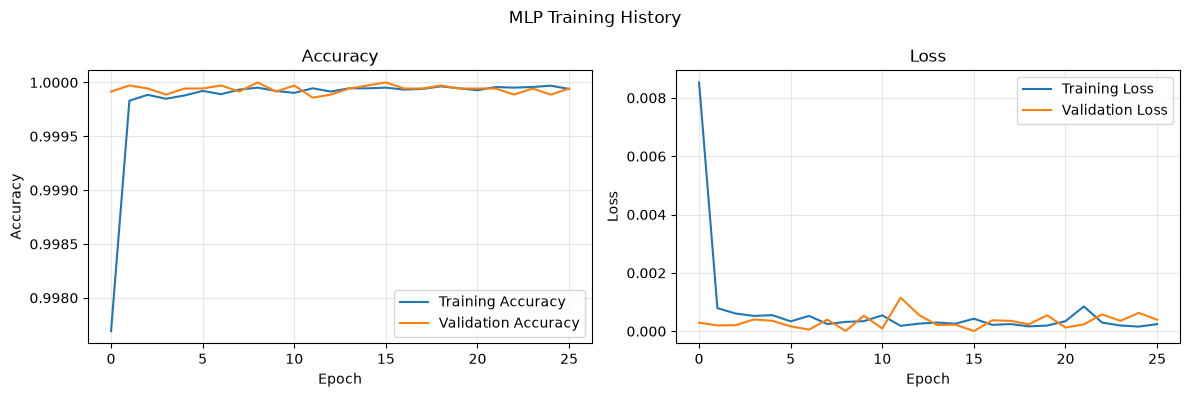

In [7]:
from pathlib import Path
Path("../results/figures").mkdir(parents=True, exist_ok=True)
plot_training_history(history, title="MLP Training History", save_path="../results/figures/mlp_training_history.png")

### 8. Evaluate on the held-out test set

The test set has not been touched until this point, no tuning, no early
stopping decisions were based on it. This is the single, fair, final check.

In [8]:
y_prob_test = model.predict(X_test)

test_metrics = calculate_metrics(y_test, y_prob_test)

print("Test set metrics:")
for k, v in test_metrics.items():
    print(f"  {k:10s}: {v:.4f}")


1106/1106 ━━━━━━━━━━━━━━━━━━━━ 1s 697us/step
Test set metrics:
  accuracy  : 0.9999
  precision : 0.9999
  recall    : 1.0000
  f1        : 0.9999
  roc_auc   : 1.0000


### 9. Confusion matrix and ROC curve

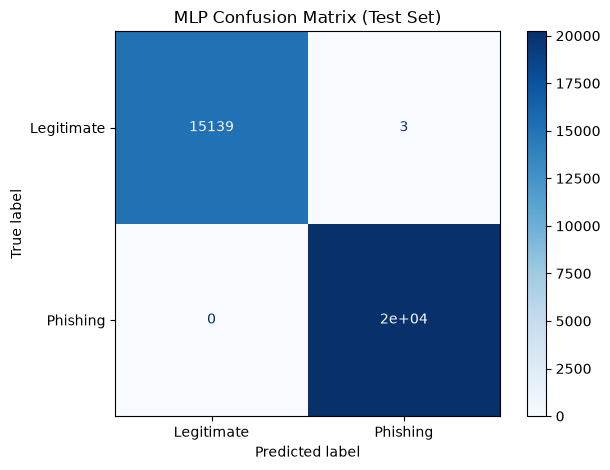

In [9]:
plot_confusion_matrix(y_test, y_prob_test, title="MLP Confusion Matrix (Test Set)", save_path="../results/figures/mlp_confusion_matrix.png")

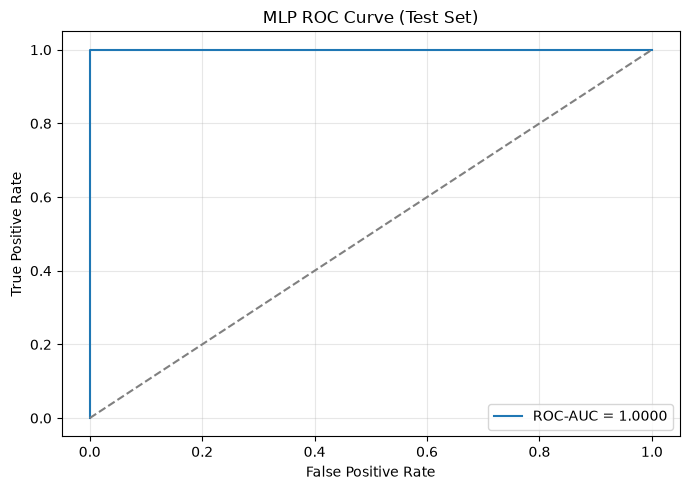

In [10]:
plot_roc_curve(y_test, y_prob_test, title="MLP ROC Curve (Test Set)", save_path="../results/figures/mlp_roc_curve.png")

### 10. Record results for the team's comparison table

In [11]:
import json

results_summary = {
    "model": "MLP",
    "epochs_ran": len(history.history["loss"]),
    "training_time_sec": round(training_time, 2),
    "trainable_parameters": int(n_params),
    "final_train_accuracy": float(history.history["accuracy"][-1]),
    "final_val_accuracy": float(history.history["val_accuracy"][-1]),
    "final_train_loss": float(history.history["loss"][-1]),
    "final_val_loss": float(history.history["val_loss"][-1]),
    "test_accuracy": test_metrics["accuracy"],
    "test_precision": test_metrics["precision"],
    "test_recall": test_metrics["recall"],
    "test_f1": test_metrics["f1"],
    "test_roc_auc": test_metrics["roc_auc"],
}

results_path = Path("../results/tables/mlp_results.json")
results_path.parent.mkdir(parents=True, exist_ok=True)

with open(results_path, "w") as f:
    json.dump(results_summary, f, indent=2)

results_summary


{'model': 'MLP',
 'epochs_ran': 26,
 'training_time_sec': 95.6,
 'trainable_parameters': 16897,
 'final_train_accuracy': 0.9999394416809082,
 'final_val_accuracy': 0.9999434351921082,
 'final_train_loss': 0.00024368480080738664,
 'final_val_loss': 0.00039537178236059844,
 'test_accuracy': 0.9999151823579304,
 'test_precision': 0.9998517127181059,
 'test_recall': 1.0,
 'test_f1': 0.9999258508613659,
 'test_roc_auc': 0.9999999085840778}

### 11. Save the trained model

In [12]:
model_path = Path("../results/mlp_model.keras")
model_path.parent.mkdir(parents=True, exist_ok=True)
model.save(model_path)
